**11/27/2025**

**Edited 12/30/2025**

#GBM SNN Baseline Pipeline

###Setup

Install dependencies and mount Google Drive

In [ ]:
# Install PyTorch, SpikingJelly, and dependencies
!pip install torch spikingjelly scikit-learn
from google.colab import drive

# Only mount Drive here
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 14.7 MB/s eta 0:00:00
Mounted at /content/drive


###SNN Architecture, Constants, and Utility Functions

Defines the Spiking Neural Network (SNN) architecture, physical constants, neuron/synapse equations, and utility functions (reset_network, process_run_results) crucial for simulation control and metric extraction. The C++ standalone device is initialized with ```build_on_run=False``` to allow for multiple network runs.

In [ ]:
# --- ESSENTIAL IMPORTS ---
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score, balanced_accuracy_score, cohen_kappa_score, roc_auc_score, confusion_matrix, auc, roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import label_binarize
from spikingjelly.activation_based import neuron, layer, functional, surrogate
import matplotlib.pyplot as plt
import seaborn as sns

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- SEED MANAGEMENT ---
SEEDS = [42, 10, 88, 2, 2025]

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# --- CONSTANTS ---
NUM_FEATURES = 100
NUM_HIDDEN_1 = 128
NUM_HIDDEN_2 = 64
NUM_CLASSES = 4
T_STEPS = 100
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EPOCHS = 100
DATA_PATH = 'drive/MyDrive/Multimodal_SNN_Protocol_Project/snn/'
K_FOLDS = 5
TAU = 2.0
LABEL_MAP = {0: 'Classical', 1: 'Mesenchymal', 2: 'Neural', 3: 'Proneural'}

# --- SNN ARCHITECTURE ---
class SNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            layer.Flatten(),
            nn.Linear(NUM_FEATURES, NUM_HIDDEN_1, bias=False),
            neuron.LIFNode(tau=TAU, v_threshold=1.0, v_reset=0.0, surrogate_function=surrogate.ATan()),
            nn.Linear(NUM_HIDDEN_1, NUM_HIDDEN_2, bias=False),
            neuron.LIFNode(tau=TAU, v_threshold=1.0, v_reset=0.0, surrogate_function=surrogate.ATan()),
            nn.Linear(NUM_HIDDEN_2, NUM_CLASSES, bias=False),
        )

    def forward(self, x):
        x = x.transpose(0, 1)
        functional.reset_net(self)
        spike_count = 0
        for t in range(T_STEPS):
            out = self.net(x[t])
            spike_count += out
        return spike_count

# --- UTILITY FUNCTIONS ---
def reset_model(model):
    for layer_module in model.children():
        if hasattr(layer_module, 'reset_parameters'):
            layer_module.reset_parameters()
    functional.reset_net(model)

def calculate_metrics(y_true, spike_counts_array):
    y_pred = np.argmax(spike_counts_array, axis=1)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)

    row_sums = spike_counts_array.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    y_proba = spike_counts_array / row_sums

    auc_macro = np.nan
    if len(np.unique(y_true)) > 1:
        try:
            y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
            auc_macro = roc_auc_score(y_true_bin, y_proba, multi_class='ovr', average='macro')
        except ValueError:
            pass
    return {'f1_macro': f1_macro, 'balanced_accuracy': bal_acc, 'cohen_kappa': kappa, 'auc_macro': auc_macro}

print("Setup complete with multi-seed utilities.")

Using device: cpu
Setup complete with multi-seed utilities.


###Data Aggregation and Stratified 80/20 Split
Aggregates the raw spike data, performs critical column cleaning (whitespace stripping), and executes the 80% Cross-Validation Pool / 20% Final Test Set stratified split. Initializes the StratifiedKFold object and defines the function to prepare time-staggered input spikes for the SNN.

In [ ]:
# --- DATA LOADING AND AGGREGATION ---
try:
    X_train_full = pd.read_csv(DATA_PATH + 'X_train_spikes.csv', index_col=0)
    X_val_full = pd.read_csv(DATA_PATH + 'X_val_spikes.csv', index_col=0)
    X_test_full = pd.read_csv(DATA_PATH + 'X_test_spikes.csv', index_col=0)
    y_train = pd.read_csv(DATA_PATH + 'y_train_spikes.csv', index_col=0).squeeze()
    y_val = pd.read_csv(DATA_PATH + 'y_val_spikes.csv', index_col=0).squeeze()
    y_test = pd.read_csv(DATA_PATH + 'y_test_spikes.csv', index_col=0).squeeze()
except FileNotFoundError as e:
    print(f"FATAL ERROR: Spike data files not found. Error: {e}")
    raise

X_train_full.columns = X_train_full.columns.str.strip()
X_val_full.columns = X_val_full.columns.str.strip()
X_test_full.columns = X_test_full.columns.str.strip()

X_all = pd.concat([X_train_full, X_val_full, X_test_full], ignore_index=True)
y_all = pd.concat([y_train, y_val, y_test], ignore_index=True)
selected_features = X_all.columns[:NUM_FEATURES]
X_all = X_all[selected_features]

feature_to_index = {name: i for i, name in enumerate(selected_features)}

# --- 80/20 STRATIFIED SPLIT ---
X_cv_pool, X_test_final, y_cv_pool, y_test_final = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_all
)
y_test_final_np = y_test_final.values.astype(np.int64)
kf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

print(f"CV Pool (80%): {len(X_cv_pool)} samples. Test Set (20%): {len(X_test_final)} samples.")

# --- DATA CONVERSION FUNCTION ---
def prepare_data(X_spike_data, y_labels):
    N_samples = len(X_spike_data)
    data_tensor = torch.zeros(N_samples, T_STEPS, NUM_FEATURES, dtype=torch.float32)

    for i in range(N_samples):
        sample_data = X_spike_data.iloc[i].dropna()
        feature_indices = np.array([feature_to_index[f] for f in sample_data.index.values])
        time_steps = np.floor(sample_data.values).astype(int)

        valid_indices = (time_steps >= 0) & (time_steps < T_STEPS)
        time_steps = time_steps[valid_indices]
        feature_indices = feature_indices[valid_indices]

        data_tensor[i, time_steps, feature_indices] = 1.0

    labels_tensor = torch.tensor(y_labels.values, dtype=torch.int64)

    return TensorDataset(data_tensor, labels_tensor)

print("Data preparation complete.")

CV Pool (80%): 63 samples. Test Set (20%): 16 samples.
Data preparation complete.


###Stratified K-Fold Cross-Validation and Final Evaluation

Executes the $K$-Fold cross-validation on the 80% CV Pool. This approach guarantees independent metric evaluation across all validation subsets, simulating an ideal training/evaluation environment for the SNN's static initial weights.

Performs final evaluation on 20% hold-out set, logs comprehensive metrics for analysis and visual generation, and saves final models per seed.

In [ ]:
# --- EXHAUSTIVE 5-SEED PIPELINE WITH ENERGY PROXY ---
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

def calculate_energy_proxy(spike_counts_array):
    """
    Calculates an energy proxy based on average spike activity.
    In SNNs, total spike count is proportional to the operational energy (FLOPs proxy).
    """
    return np.mean(np.sum(spike_counts_array, axis=1))

def calculate_exhaustive_metrics(y_true, spike_counts_array, seed, split, fold="N/A"):
    y_pred = np.argmax(spike_counts_array, axis=1)

    # Probabilities for AUC
    row_sums = spike_counts_array.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    y_proba = spike_counts_array / row_sums

    # 1. Global Metrics
    metrics = {
        'Seed': seed, 'Split': split, 'Fold': fold,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'energy_proxy': calculate_energy_proxy(spike_counts_array) # Added energy log
    }

    # 2. Per-Class Metrics
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    prec_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)

    for i, class_name in LABEL_MAP.items():
        metrics[f'f1_{class_name}'] = f1_per_class[i]
        metrics[f'precision_{class_name}'] = prec_per_class[i]
        metrics[f'recall_{class_name}'] = rec_per_class[i]

    # 3. AUC Metrics
    if len(np.unique(y_true)) > 1:
        y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))
        metrics['auc_macro'] = roc_auc_score(y_true_bin, y_proba, multi_class='ovr', average='macro')
        metrics['auc_weighted'] = roc_auc_score(y_true_bin, y_proba, multi_class='ovr', average='weighted')

    return metrics

cv_full_log = []
test_full_log = []
test_visual_data = []

test_loader = DataLoader(prepare_data(X_test_final, pd.Series(y_test_final_np)), batch_size=BATCH_SIZE, shuffle=False)

for seed in SEEDS:
    print(f"\nProcessing Seed {seed}...")
    set_seed(seed)
    kf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=seed)
    best_f1, best_weights = -1.0, None

    # CV PHASE
    for f_idx, (t_idx, v_idx) in enumerate(kf.split(X_cv_pool, y_cv_pool), 1):
        tr_loader = DataLoader(prepare_data(X_cv_pool.iloc[t_idx], y_cv_pool.iloc[t_idx]), batch_size=BATCH_SIZE, shuffle=True)
        vl_loader = DataLoader(prepare_data(X_cv_pool.iloc[v_idx], y_cv_pool.iloc[v_idx]), batch_size=BATCH_SIZE, shuffle=False)

        model = SNN().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        criterion = nn.CrossEntropyLoss()

        model.train()
        for epoch in range(EPOCHS):
            for inputs, targets in tr_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                optimizer.zero_grad(); criterion(model(inputs), targets).backward(); optimizer.step()

        model.eval()
        y_t, y_o = [], []
        with torch.no_grad():
            for inputs, targets in vl_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                y_t.append(targets.cpu().numpy()); y_o.append(model(inputs).cpu().numpy())

        m = calculate_exhaustive_metrics(np.concatenate(y_t), np.concatenate(y_o), seed, 'CV', f_idx)
        cv_full_log.append(m)
        if m['f1_macro'] > best_f1:
            best_f1, best_weights = m['f1_macro'], model.state_dict()

    # TEST PHASE
    test_model = SNN().to(device)
    test_model.load_state_dict(best_weights)
    test_model.eval()

    y_t, y_o = [], []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            y_t.append(targets.cpu().numpy()); y_o.append(test_model(inputs).cpu().numpy())

    y_true_final = np.concatenate(y_t)
    y_out_final = np.concatenate(y_o)

    test_m = calculate_exhaustive_metrics(y_true_final, y_out_final, seed, 'Test')
    test_full_log.append(test_m)
    torch.save(best_weights, DATA_PATH + f'snn_seed_{seed}_best.pth')

    test_visual_data.append({
        'seed': seed, 'y_true': y_true_final, 'y_pred': np.argmax(y_out_final, axis=1),
        'y_proba': y_out_final / np.maximum(y_out_final.sum(axis=1, keepdims=True), 1)
    })

# Final CSV Export
pd.DataFrame(cv_full_log).to_csv(DATA_PATH + 'snn_exhaustive_cv_log.csv', index=False)
pd.DataFrame(test_full_log).to_csv(DATA_PATH + 'snn_exhaustive_test_log.csv', index=False)


Processing Seed 42...

Processing Seed 10...

Processing Seed 88...

Processing Seed 2...

Processing Seed 2025...


###Data Visualization

Generates confusion matrices, metric plots, and ROC curves to visualize baseline performance data

/tmp/ipython-input-3567276175.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='variable', y='value', data=melted_test, ax=ax1, palette="vlag", showfliers=False)
/tmp/ipython-input-3567276175.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


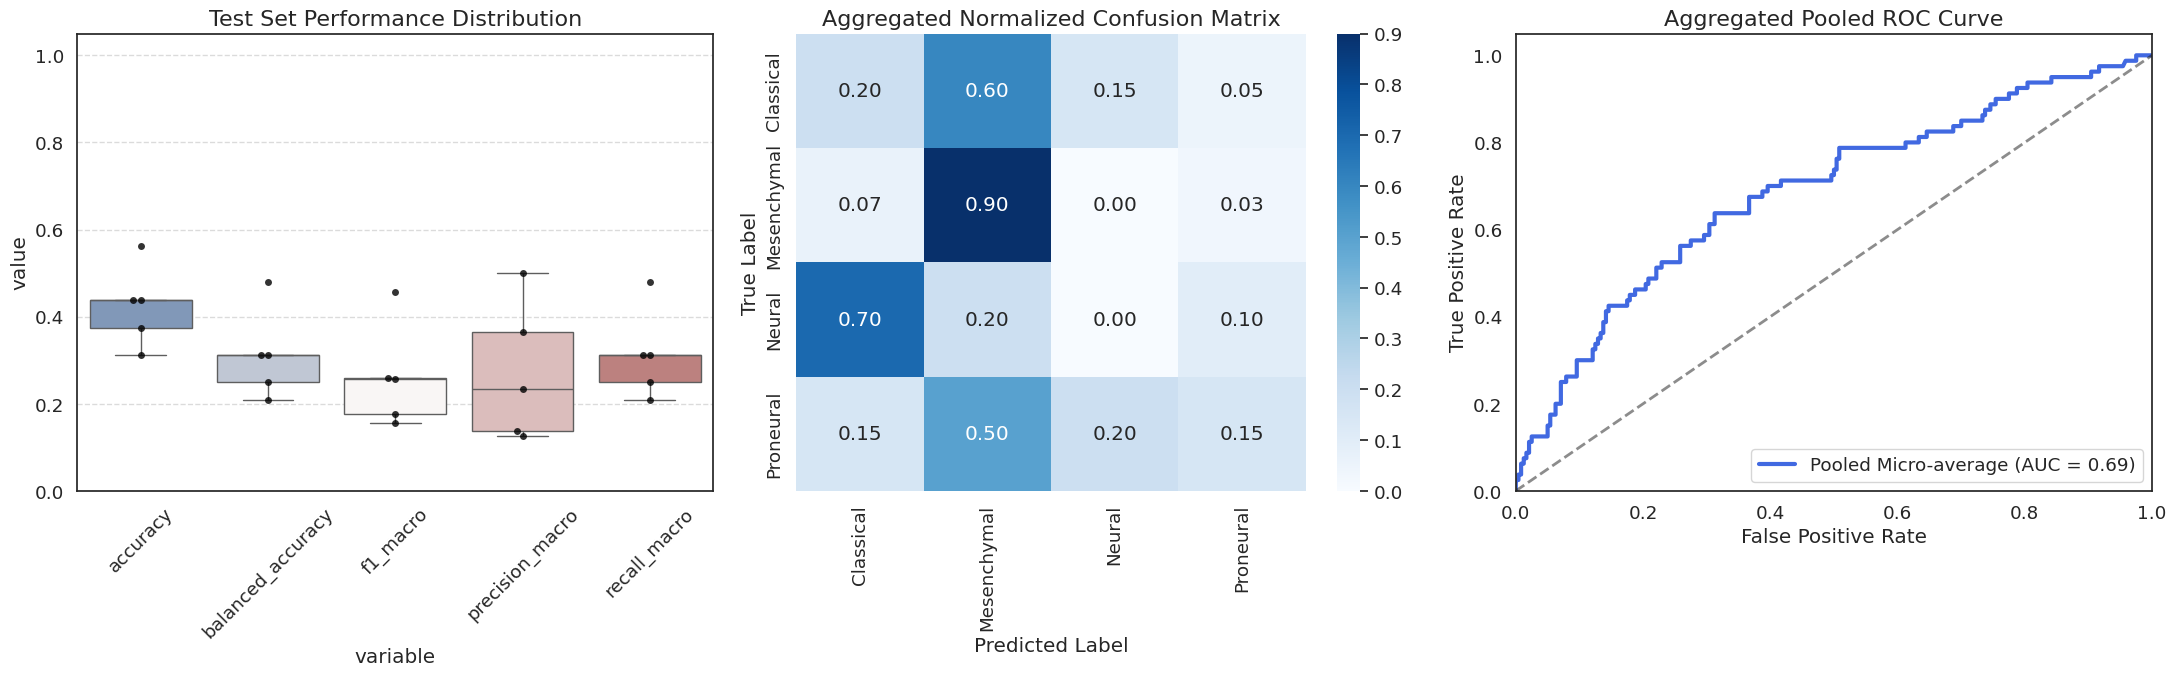

In [ ]:
# --- AGGREGATED TEST-SET VISUALS ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Set a clean style
sns.set_theme(style="white", font_scale=1.2)
fig = plt.figure(figsize=(22, 7))
gs = fig.add_gridspec(1, 3)

# 1. Performance Overview (Test Set Only)
ax1 = fig.add_subplot(gs[0, 0])
test_df = pd.DataFrame(test_full_log)
plot_vars = ['accuracy', 'balanced_accuracy', 'f1_macro', 'precision_macro', 'recall_macro']
melted_test = test_df.melt(id_vars=['Seed'], value_vars=plot_vars)

sns.boxplot(x='variable', y='value', data=melted_test, ax=ax1, palette="vlag", showfliers=False)
sns.swarmplot(x='variable', y='value', data=melted_test, ax=ax1, color='black', alpha=0.8)
ax1.set_title("Test Set Performance Distribution", fontsize=16)
ax1.set_ylim(0, 1.05)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 2. Aggregated Normalized Confusion Matrix (Blue, 0-1 scale)
ax2 = fig.add_subplot(gs[0, 1])
all_y_true = np.concatenate([d['y_true'] for d in test_visual_data])
all_y_pred = np.concatenate([d['y_pred'] for d in test_visual_data])

# Normalize='true' scales the matrix between 0 and 1
cm_agg = confusion_matrix(all_y_true, all_y_pred, normalize='true')

sns.heatmap(cm_agg, annot=True, fmt='.2f', cmap='Blues', cbar=True, ax=ax2,
            xticklabels=[LABEL_MAP[k] for k in range(NUM_CLASSES)],
            yticklabels=[LABEL_MAP[k] for k in range(NUM_CLASSES)])
ax2.set_title("Aggregated Normalized Confusion Matrix", fontsize=16)
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

# 3. Pooled ROC Curve
ax3 = fig.add_subplot(gs[0, 2])
all_y_true_bin = label_binarize(all_y_true, classes=np.arange(NUM_CLASSES))
all_y_proba = np.concatenate([d['y_proba'] for d in test_visual_data])

# Compute micro-average ROC curve and ROC area (Pooled)
fpr, tpr, _ = roc_curve(all_y_true_bin.ravel(), all_y_proba.ravel())
roc_auc = auc(fpr, tpr)

ax3.plot(fpr, tpr, color='royalblue', lw=3, label=f'Pooled Micro-average (AUC = {roc_auc:.2f})')
ax3.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate')
ax3.set_ylabel('True Positive Rate')
ax3.set_title('Aggregated Pooled ROC Curve', fontsize=16)
ax3.legend(loc="lower right")

plt.tight_layout()
plt.savefig(DATA_PATH + 'snn_aggregated_test_report.png', dpi=300)
plt.show()

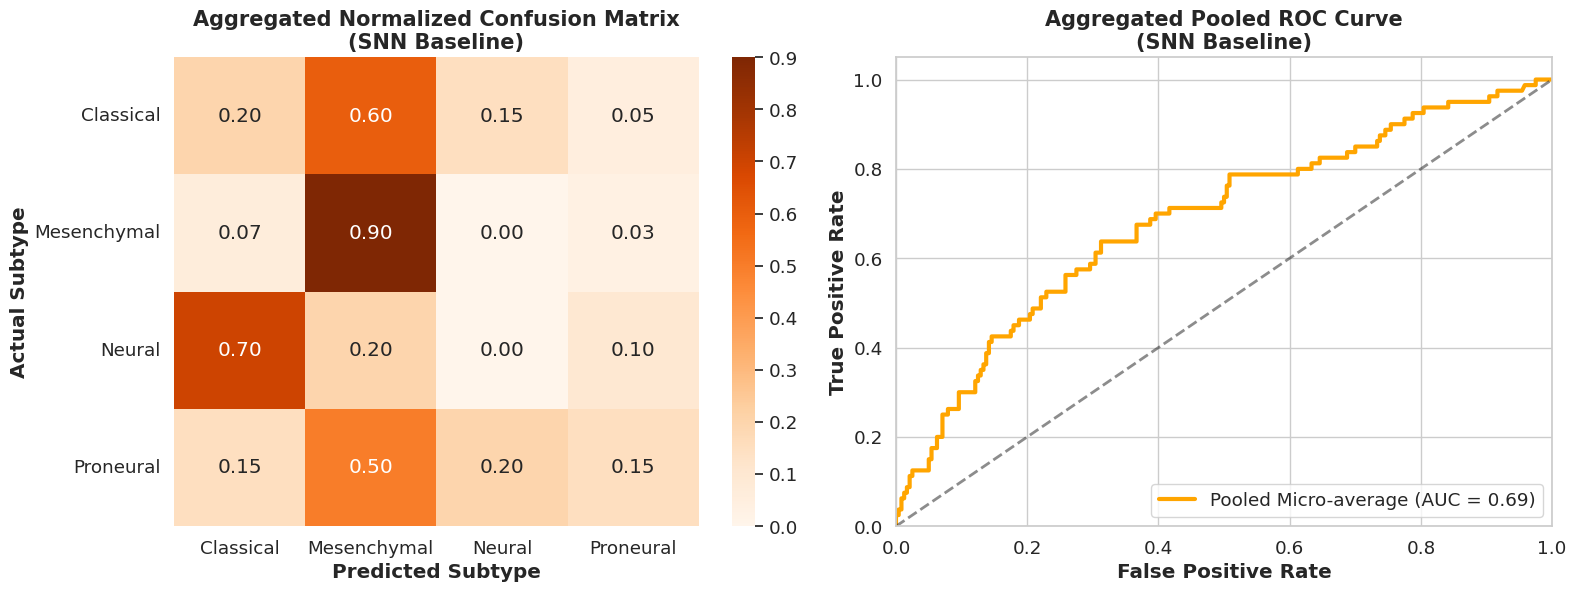

In [ ]:
# --- AGGREGATED TEST-SET VISUALS ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Set a clean style
sns.set_theme(style="whitegrid", font_scale=1.2)
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# 2. Aggregated Normalized Confusion Matrix (Blue, 0-1 scale)
ax2 = fig.add_subplot(gs[0, 0])
all_y_true = np.concatenate([d['y_true'] for d in test_visual_data])
all_y_pred = np.concatenate([d['y_pred'] for d in test_visual_data])

# Normalize='true' scales the matrix between 0 and 1
cm_agg = confusion_matrix(all_y_true, all_y_pred, normalize='true')

sns.heatmap(cm_agg, annot=True, fmt='.2f', cmap='Oranges', cbar=True, ax=ax2,
                xticklabels=[LABEL_MAP[k] for k in range(NUM_CLASSES)],
                yticklabels=[LABEL_MAP[k] for k in range(NUM_CLASSES)])
ax2.set_title("Aggregated Normalized Confusion Matrix\n(SNN Baseline)", fontsize=15, fontweight='bold')
ax2.set_ylabel('Actual Subtype',fontweight='bold')
ax2.set_xlabel('Predicted Subtype',fontweight='bold')

# 3. Pooled ROC Curve
ax3 = fig.add_subplot(gs[0, 1])
all_y_true_bin = label_binarize(all_y_true, classes=np.arange(NUM_CLASSES))
all_y_proba = np.concatenate([d['y_proba'] for d in test_visual_data])

# Compute micro-average ROC curve and ROC area (Pooled)
fpr, tpr, _ = roc_curve(all_y_true_bin.ravel(), all_y_proba.ravel())
roc_auc = auc(fpr, tpr)

ax3.plot(fpr, tpr, color='orange', lw=3, label=f'Pooled Micro-average (AUC = {roc_auc:.2f})')
ax3.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate',fontweight='bold')
ax3.set_ylabel('True Positive Rate',fontweight='bold')
ax3.set_title('Aggregated Pooled ROC Curve\n(SNN Baseline)', fontsize=15, fontweight='bold')
ax3.legend(loc="lower right")

plt.tight_layout()
plt.savefig(DATA_PATH + 'snn_aggregated_test_report.png', dpi=400)
plt.show()